# Classification Evaluation

**Goal:** compare the project specialty classifier (S-PubMedBert + MLP head, trained on Medical Transcriptions per Phase 4.2) against two `sklearn.dummy.DummyClassifier` baselines on the held-out mtsamples test split.

**Compared models:**

1. **Trained**: `src.pipeline.classifier.predict_batch()` (project wrapper, encodes inputs via S-PubMedBert internally then calls the saved MLP head).
2. **`DummyClassifier(strategy="most_frequent")`**: predicts the single most common training class on every row.
3. **`DummyClassifier(strategy="stratified")`**: samples a label per row using training class proportions.

**Metrics:** accuracy (lead), per-class Precision / Recall / F1 (trained model only, dummies are mechanical), macro-F1, weighted-F1.

**Test-split note:** mtsamples is not published with a pre-existing split. `scripts/train_classifier.py` does an inline `train_test_split(test_size=0.2, stratify=y, random_state=42)`. This notebook reproduces the exact same load + filter + concat + preprocess + split pipeline with the same constants and `random_state`, so the test slice here is byte-identical to the one the trained model never saw.


In [ ]:
import sys
import time
from pathlib import Path

import pandas as pd

# Project import path: notebooks/ lives one level under the repo root
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from src.utils.config import RAG_SOURCES, RESULTS_DIR
from src.pipeline import (
    classifier as classifier_wrapper,
)  # same wrapper that runs in the UI
from src.pipeline.preprocessing import (
    preprocess,
)  # training applied this; eval must match

c:\Users\Admin\anaconda3\Lib\site-packages\spacy\util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


In [2]:
# These three constants MUST match scripts/train_classifier.py exactly. If they
# drift, the recovered test split will not be the same set the trained model was
# evaluated on, and the wrapper might be asked to predict on classes it never saw.
MIN_SAMPLES_PER_CLASS = 10
RANDOM_STATE = 42
DROP_LABELS = {
    "Surgery",
    "Consult - History and Phy.",
    "General Medicine",
    "SOAP / Chart / Progress Notes",
    "Discharge Summary",
    "Emergency Room Reports",
    "Office Notes",
    "Letters",
    "IME-QME-Work Comp etc.",
}

In [ ]:
# Load cleaned mtsamples, apply the same filters training used
df = pd.read_csv(RAG_SOURCES["medical_transcriptions"])
print(f"Raw rows: {len(df):,}   raw specialties: {df['specialty'].nunique()}")

# Drop document-type and overly-generic labels (matches training)
df = df[~df["specialty"].isin(DROP_LABELS)].reset_index(drop=True)
print(
    f"After DROP_LABELS:        {len(df):,} rows   {df['specialty'].nunique()} specialties"
)

# Drop specialties with < MIN_SAMPLES_PER_CLASS rows (matches training)
counts = df["specialty"].value_counts()
keep = counts[counts >= MIN_SAMPLES_PER_CLASS].index
df = df[df["specialty"].isin(keep)].reset_index(drop=True)
print(
    f"After MIN_SAMPLES filter: {len(df):,} rows   {df['specialty'].nunique()} specialties"
)

# Drop rows whose text column is null (matches training)
df = df.dropna(subset=["text"]).reset_index(drop=True)
print(
    f"After dropna(text):       {len(df):,} rows   {df['specialty'].nunique()} specialties"
)

# Build the same combined input training used: text + description + keywords, then preprocess
t0 = time.perf_counter()
raw = (
    df["text"].fillna("").astype(str)
    + " "
    + df["description"].fillna("").astype(str)
    + " "
    + df["keywords"].fillna("").astype(str)
)
df["clean"] = raw.map(preprocess)
print(f"preprocess: {time.perf_counter() - t0:.1f}s")

Raw rows: 4,966   raw specialties: 40
After DROP_LABELS:        2,665 rows   31 specialties
After MIN_SAMPLES filter: 2,627 rows   26 specialties
After dropna(text):       2,627 rows   26 specialties
preprocess: 0.5s


In [ ]:
# Reproduce the exact training split. LabelEncoder integer y is required for the
# stratified split to land identically, because that's what train_classifier.py
# fed into train_test_split.
le = LabelEncoder()
y_int = le.fit_transform(df["specialty"].tolist())

X_text_train, X_text_test, y_train_int, y_test_int = train_test_split(
    df["clean"].tolist(),
    y_int,
    test_size=0.2,
    stratify=y_int,
    random_state=RANDOM_STATE,
)

y_train = le.inverse_transform(y_train_int).tolist()
y_test = le.inverse_transform(y_test_int).tolist()

# Test_df is rebuilt aligned to the test split so the inspection cells below have
# the original specialty + raw-ish text fields per row alongside the cleaned input.
split_meta = train_test_split(
    df,
    y_int,
    test_size=0.2,
    stratify=y_int,
    random_state=RANDOM_STATE,
)
test_df = split_meta[1].reset_index(drop=True)

print(
    f"Train: {len(X_text_train):,} rows   Test: {len(X_text_test):,} rows   Classes: {len(le.classes_)}"
)

Train: 2,101 rows   Test: 526 rows   Classes: 26


## Inspecting the test set

Quick look at the shape and label distribution before evaluating.


In [ ]:
# First 10 test rows. Description is what the user would type in the demo, so we
# show it alongside the full specialty label the model has to recover.
preview = pd.DataFrame(
    [
        {
            "specialty": r["specialty"],
            "description": (
                (str(r["description"])[:60] + "...")
                if len(str(r["description"])) > 60
                else str(r["description"])
            ),
            "keywords": (
                (str(r["keywords"])[:50] + "...")
                if len(str(r["keywords"])) > 50
                else str(r["keywords"])
            ),
            "text_len": len(str(r["text"])),
        }
        for _, r in test_df.head(10).iterrows()
    ]
)
preview

,specialty,description,keywords,text_len
0,Orthopedic,Common CT C-Spine template,"orthopedic, sequential axial ct images, atlant...",712
1,Radiology,Cardiolite treadmill exercise stress test. Th...,"radiology, peak heart rate, bundle branch bloc...",1371
2,Pain Management,"Intercostal block, left. Severe post thoraco...","pain management, thoracotomy pain, intercostal...",604
3,Pediatrics - Neonatal,A 2-1/2-year-old female with history of febril...,nan,4860
4,ENT - Otolaryngology,Repair of bilateral cleft of the palate with v...,"ent - otolaryngology, bilateral cleft, cleft l...",5262
5,Cardiovascular / Pulmonary,Dobutamine Stress Echocardiogram. Chest disco...,"cardiovascular / pulmonary, chest discomfort, ...",2792
6,Chiropractic,Chiropractic Evaluation for neck and low back ...,nan,3332
7,Orthopedic,Followup status post L4-L5 laminectomy and bil...,"orthopedic, spinal fusion, restless leg syndro...",4523
8,Dentistry,Carious teeth and periodontal disease affectin...,"dentistry, intraoral procedure, partial bony i...",2452
9,Neurosurgery,Left C5-6 hemilaminotomy and foraminotomy with...,"neurosurgery, foraminotomy with medial facetec...",3271


In [ ]:
# Class distribution train vs test. Sorted by train count descending so the head
# specialties (which dominate accuracy) appear first. The trained model should do
# best on these and worst on the long tail.
train_counts = pd.Series(y_train).value_counts()
test_counts = pd.Series(y_test).value_counts()

dist = (
    pd.DataFrame(
        {
            "train": train_counts,
            "test": test_counts,
        }
    )
    .fillna(0)
    .astype(int)
)
dist = dist.sort_values("train", ascending=False)
dist["train_share"] = (dist["train"] / dist["train"].sum()).map(lambda x: f"{x:.1%}")
dist

,train,test,train_share
Cardiovascular / Pulmonary,297,74,14.1%
Orthopedic,284,71,13.5%
Radiology,218,55,10.4%
Gastroenterology,179,45,8.5%
Neurology,178,45,8.5%
Urology,125,31,5.9%
Obstetrics / Gynecology,124,31,5.9%
ENT - Otolaryngology,77,19,3.7%
Neurosurgery,75,19,3.6%
Hematology - Oncology,72,18,3.4%


In [ ]:
# 3 sample test rows with their specialty and a snippet of the description field.
# Gives the reader a feel for what the model is being asked to discriminate.
for _, r in test_df.head(3).iterrows():
    print(f"[{r['specialty']}]")
    print(
        f"  description: {str(r['description'])[:160]}{'...' if len(str(r['description'])) > 160 else ''}"
    )
    print()

[Orthopedic]
  description: Common CT C-Spine template

[Radiology]
  description: Cardiolite treadmill exercise stress test.  The patient was exercised on the treadmill to maximum tolerance achieving after 5 minutes a peak heart rate of 137 b...

[Pain Management]
  description: Intercostal block, left.   Severe post thoracotomy pain.



## Predictions

Three predictors:

- **Trained model**: through `classifier_wrapper.predict_batch()`, which internally encodes each input via S-PubMedBert (~768d, L2-normalised) and calls the MLP head. Slow step: encoding ~1k test rows on CPU takes a few minutes.
- **Dummy (most_frequent)**: fit on training labels, predicts the single most common training class for every test row.
- **Dummy (stratified)**: fit on training labels, samples a label per test row using training class proportions.


In [8]:
# Trained model: one batched call. The wrapper handles PubMedBert encoding + MLP
# predict_proba + argmax + classes_ lookup internally; we only need the label.
t0 = time.perf_counter()
trained_preds = [p["label"] for p in classifier_wrapper.predict_batch(X_text_test)]
t_trained = time.perf_counter() - t0
print(f"trained: {t_trained:.1f}s on {len(X_text_test):,} rows")

W0517 03:18:32.165000 22604 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: pritamdeka/S-PubMedBert-MS-MARCO
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trained: 17.6s on 526 rows


In [ ]:
# Both dummies need an X argument but only look at y during fit. We pass a list
# of zero arrays of the right length so sklearn's shape check is satisfied.
X_train_dummy = [[0]] * len(y_train)
X_test_dummy = [[0]] * len(y_test)

# most_frequent: predicts the argmax of the training class distribution every time
t0 = time.perf_counter()
dummy_most = DummyClassifier(strategy="most_frequent", random_state=0)
dummy_most.fit(X_train_dummy, y_train)
most_preds = dummy_most.predict(X_test_dummy).tolist()
t_most = time.perf_counter() - t0
majority_class = dummy_most.classes_[dummy_most.class_prior_.argmax()]
print(f"dummy most_frequent: {t_most:.2f}s  (always predicts {majority_class!r})")

# stratified: samples a label per row from the training class distribution.
# Fixed random_state so the eval is reproducible across runs.
t0 = time.perf_counter()
dummy_strat = DummyClassifier(strategy="stratified", random_state=0)
dummy_strat.fit(X_train_dummy, y_train)
strat_preds = dummy_strat.predict(X_test_dummy).tolist()
t_strat = time.perf_counter() - t0
print(f"dummy stratified:    {t_strat:.2f}s")

dummy most_frequent: 0.00s  (always predicts 'Cardiovascular / Pulmonary')
dummy stratified:    0.00s


## Per-model metrics

Overall numbers for all three predictors (accuracy, macro-F1, weighted-F1). Per-class breakdown only for the trained model (the dummy per-class numbers are mechanical: most_frequent has F1=0 on 25 of 26 classes; stratified has F1 proportional to the class prior, so the per-class table adds no signal beyond the overall ones).


In [ ]:
# Use the trained model's class set as the reference. Dummies trained on the same
# y_train have the same classes_.
LABELS = sorted(set(y_train))


def overall(name, y_pred):
    """Lead with accuracy, then macro-F1, then weighted-F1. Returns the three
    numbers as a dict so the chart cell below can plot them without recomputing."""
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro", labels=LABELS, zero_division=0)
    weighted_f1 = f1_score(
        y_test, y_pred, average="weighted", labels=LABELS, zero_division=0
    )
    print(f"=== {name} ===")
    print(f"  Accuracy:    {acc:.4f}")
    print(f"  macro-F1:    {macro_f1:.4f}")
    print(f"  weighted-F1: {weighted_f1:.4f}")
    print()
    return {"accuracy": acc, "macro_f1": macro_f1, "weighted_f1": weighted_f1}


metrics_trained = overall("Trained (S-PubMedBert + MLP)", trained_preds)
metrics_most = overall("DummyClassifier(most_frequent)", most_preds)
metrics_strat = overall("DummyClassifier(stratified)", strat_preds)

=== Trained (S-PubMedBert + MLP) ===
  Accuracy:    0.6217
  macro-F1:    0.4098
  weighted-F1: 0.5896

=== DummyClassifier(most_frequent) ===
  Accuracy:    0.1407
  macro-F1:    0.0095
  weighted-F1: 0.0347

=== DummyClassifier(stratified) ===
  Accuracy:    0.0837
  macro-F1:    0.0364
  weighted-F1: 0.0821



In [11]:
# Per-class table for the trained model only, sorted by support descending so the
# head specialties (which dominate accuracy) appear first.
p, r, f, support = precision_recall_fscore_support(
    y_test, trained_preds, labels=LABELS, zero_division=0
)
rows = sorted(zip(LABELS, p, r, f, support), key=lambda x: -x[4])

print("Trained model: per-class metrics (sorted by support desc)")
print(f"  {'class':<35}{'Precision':>12}{'Recall':>10}{'F1':>10}{'support':>10}")
for cls, pi, ri, fi, si in rows:
    print(f"  {cls:<35}{pi:>12.4f}{ri:>10.4f}{fi:>10.4f}{si:>10,}")

Trained model: per-class metrics (sorted by support desc)
  class                                 Precision    Recall        F1   support
  Cardiovascular / Pulmonary               0.6966    0.8378    0.7607        74
  Orthopedic                               0.6429    0.7606    0.6968        71
  Radiology                                0.3095    0.2364    0.2680        55
  Gastroenterology                         0.7692    0.8889    0.8247        45
  Neurology                                0.4151    0.4889    0.4490        45
  Obstetrics / Gynecology                  0.7879    0.8387    0.8125        31
  Urology                                  0.7714    0.8710    0.8182        31
  ENT - Otolaryngology                     0.7368    0.7368    0.7368        19
  Neurosurgery                             0.4583    0.5789    0.5116        19
  Hematology - Oncology                    0.3333    0.3889    0.3590        18
  Ophthalmology                            0.6957    0.9412   

## Comparison chart

Overall accuracy / macro-F1 / weighted-F1 grouped by the three predictors. Per-class bars would be 78 wide on a 26-class problem; the overall view is what tells the story. Saved as a PNG for the report.


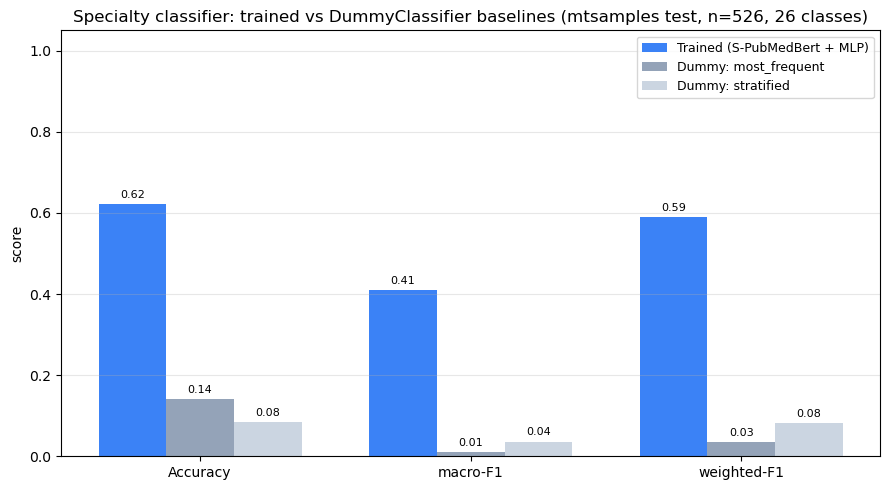

In [ ]:
import matplotlib.pyplot as plt

# results/ is the project's standard artifact directory
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
chart_path = RESULTS_DIR / "classifier_eval_chart.png"

# x-axis: one slot per metric
metric_names = ["Accuracy", "macro-F1", "weighted-F1"]
metric_keys = ["accuracy", "macro_f1", "weighted_f1"]
x_positions = list(range(len(metric_names)))
bar_width = (
    0.25  # three bars per slot -> each takes 1/3 of the slot width with a small gap
)

# Pull the three numbers per model in metric order
trained_vals = [metrics_trained[k] for k in metric_keys]
most_vals = [metrics_most[k] for k in metric_keys]
strat_vals = [metrics_strat[k] for k in metric_keys]

fig, ax = plt.subplots(figsize=(9, 5))

bars_t = ax.bar(
    [i - bar_width for i in x_positions],
    trained_vals,
    bar_width,
    label="Trained (S-PubMedBert + MLP)",
    color="#3b82f6",
)
bars_m = ax.bar(
    [i for i in x_positions],
    most_vals,
    bar_width,
    label="Dummy: most_frequent",
    color="#94a3b8",
)
bars_s = ax.bar(
    [i + bar_width for i in x_positions],
    strat_vals,
    bar_width,
    label="Dummy: stratified",
    color="#cbd5e1",
)

# Numeric labels on top of every bar so the reader does not have to eyeball the y axis
for group in (bars_t, bars_m, bars_s):
    for bar in group:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.01,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.set_xticks(x_positions)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title(
    f"Specialty classifier: trained vs DummyClassifier baselines (mtsamples test, n={len(y_test):,}, {len(LABELS)} classes)"
)
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="upper right", fontsize=9)

fig.tight_layout()
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()